In [31]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
# fetch dataset
adult = fetch_ucirepo(id=2)

In [32]:
X = adult.data.features
y = adult.data.targets

In [33]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [34]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [35]:
y['income'].unique()

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

In [36]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   income  48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


Forma del dataset: (48842, 15)

Tipos de datos:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Vista rápida:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K



Valores faltantes por columna (top):


,missing
occupation,966
workclass,963
native-country,274


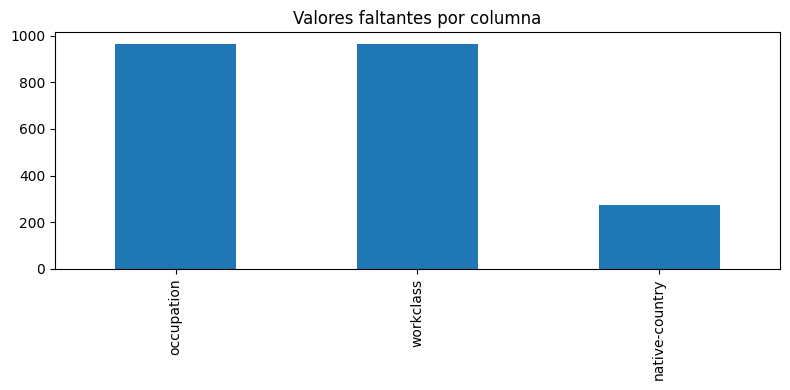


Filas duplicadas: 29


In [37]:

# nombre de la variable objetivo (Adult suele ser 'income')
target = y.columns[0]

# Unimos para EDA integral
df = pd.concat([X, y], axis=1)

print("Forma del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nVista rápida:")
display(df.head(10))

# =======================
# 2) FALTANTES Y DUPLICADOS
# =======================
na = df.isna().sum().sort_values(ascending=False)
print("\nValores faltantes por columna (top):")
display(na.to_frame("missing").query("missing>0").head(50))

plt.figure(figsize=(8,4))
na[na>0].plot(kind="bar")
plt.title("Valores faltantes por columna")
plt.tight_layout(); plt.show()

dups = df.duplicated().sum()
print(f"\nFilas duplicadas: {dups}")

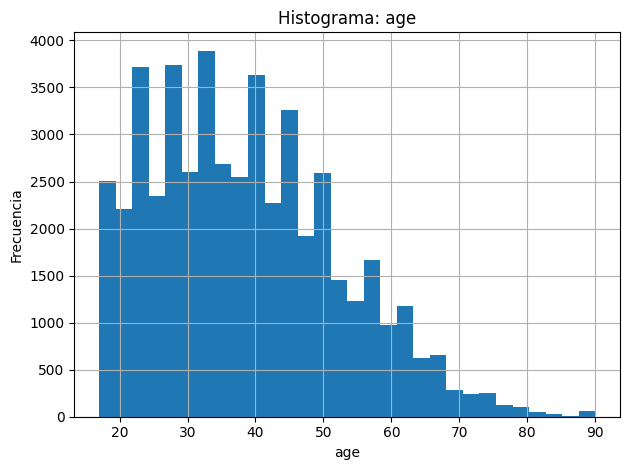

[age] n=48842 | mean=38.644 | std=13.711 | min=17.000 | q1=28.000 | median=37.000 | q3=48.000 | max=90.000


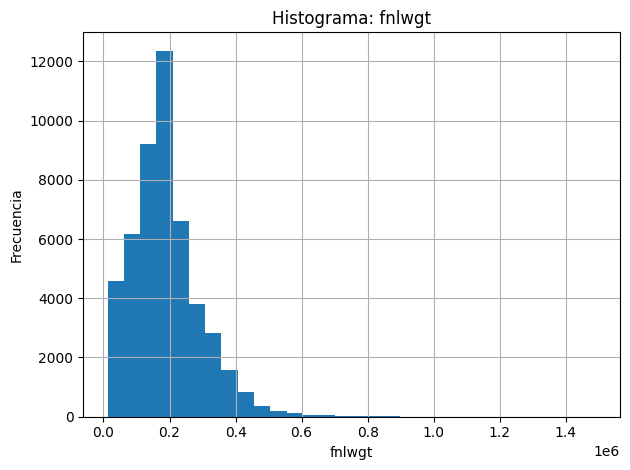

[fnlwgt] n=48842 | mean=189664.135 | std=105604.025 | min=12285.000 | q1=117550.500 | median=178144.500 | q3=237642.000 | max=1490400.000


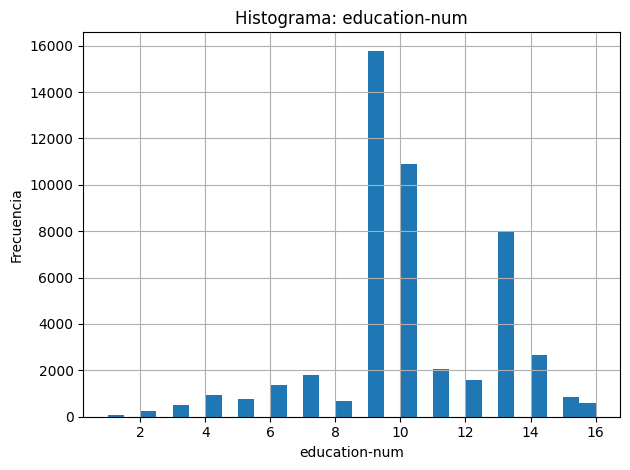

[education-num] n=48842 | mean=10.078 | std=2.571 | min=1.000 | q1=9.000 | median=10.000 | q3=12.000 | max=16.000


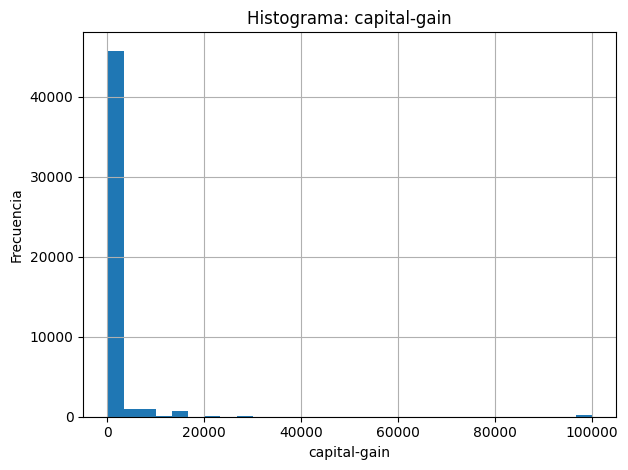

[capital-gain] n=48842 | mean=1079.068 | std=7452.019 | min=0.000 | q1=0.000 | median=0.000 | q3=0.000 | max=99999.000


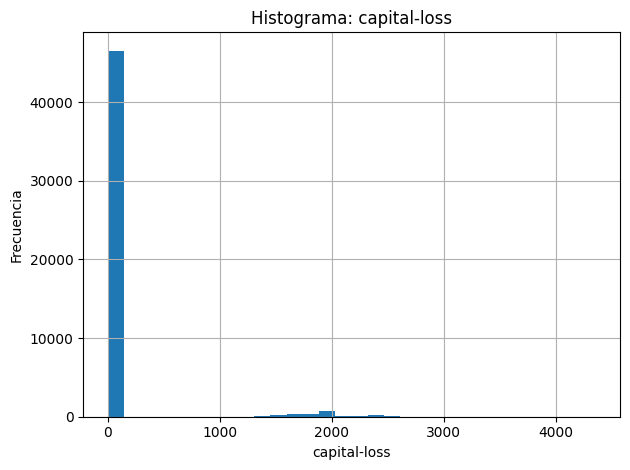

[capital-loss] n=48842 | mean=87.502 | std=403.005 | min=0.000 | q1=0.000 | median=0.000 | q3=0.000 | max=4356.000


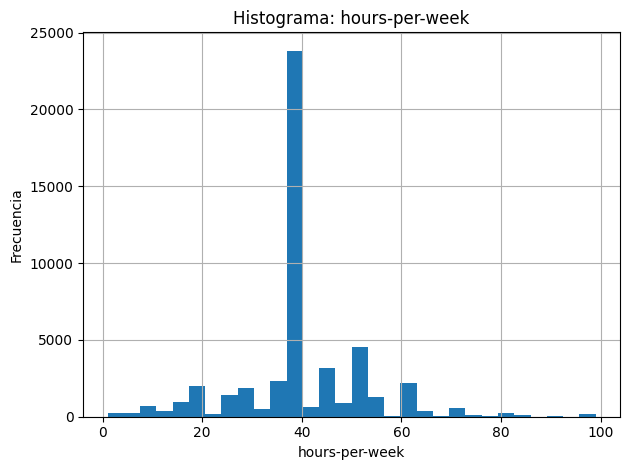

[hours-per-week] n=48842 | mean=40.422 | std=12.391 | min=1.000 | q1=40.000 | median=40.000 | q3=45.000 | max=99.000

Categorías en workclass (top 20):


,freq
workclass,
Private,33906
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
?,1836
Self-emp-inc,1695
Federal-gov,1432
<NA>,963
Without-pay,21


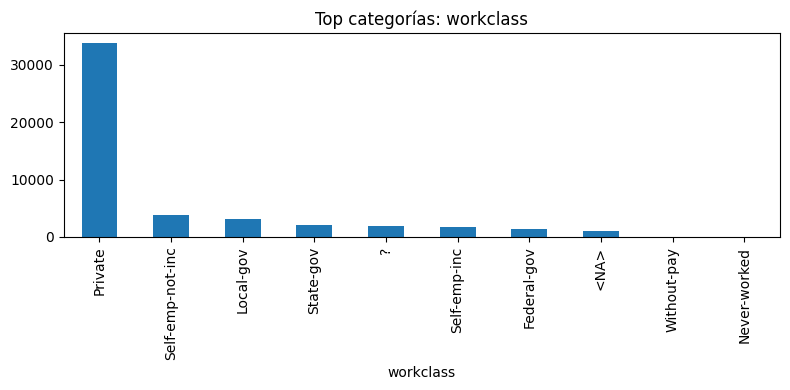


Categorías en education (top 20):


,freq
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


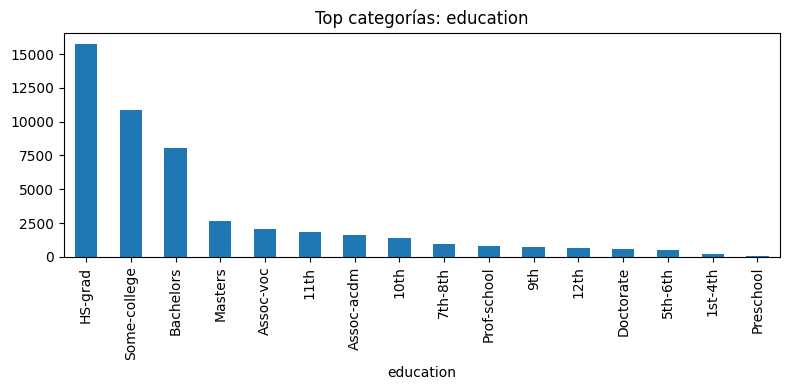


Categorías en marital-status (top 20):


,freq
marital-status,
Married-civ-spouse,22379
Never-married,16117
Divorced,6633
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


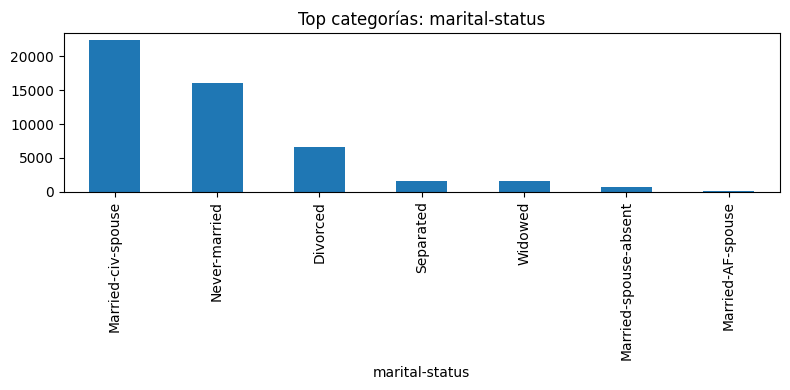


Categorías en occupation (top 20):


,freq
occupation,
Prof-specialty,6172
Craft-repair,6112
Exec-managerial,6086
Adm-clerical,5611
Sales,5504
Other-service,4923
Machine-op-inspct,3022
Transport-moving,2355
Handlers-cleaners,2072


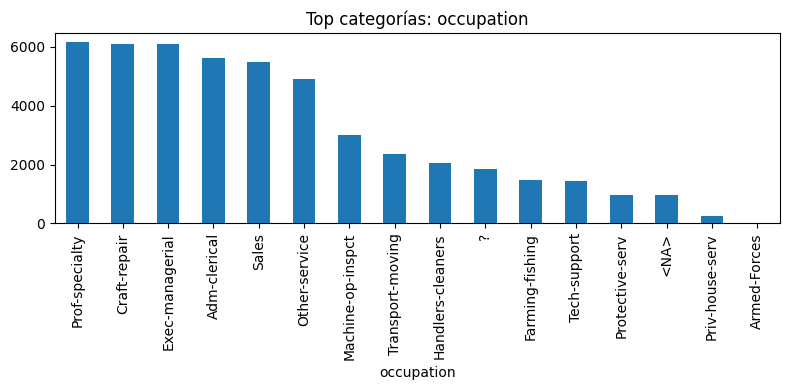


Categorías en relationship (top 20):


,freq
relationship,
Husband,19716
Not-in-family,12583
Own-child,7581
Unmarried,5125
Wife,2331
Other-relative,1506


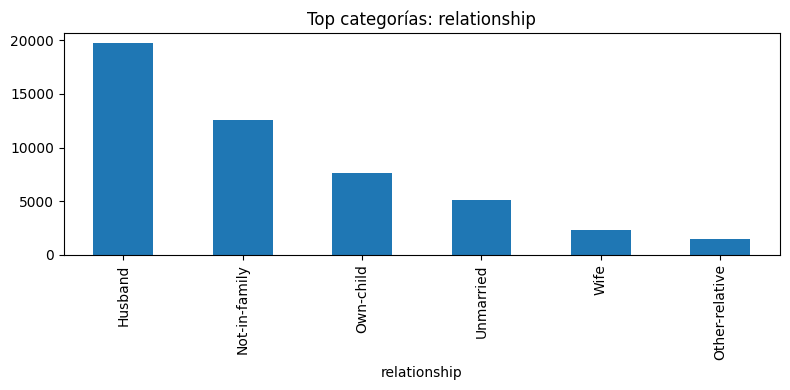


Categorías en race (top 20):


,freq
race,
White,41762
Black,4685
Asian-Pac-Islander,1519
Amer-Indian-Eskimo,470
Other,406


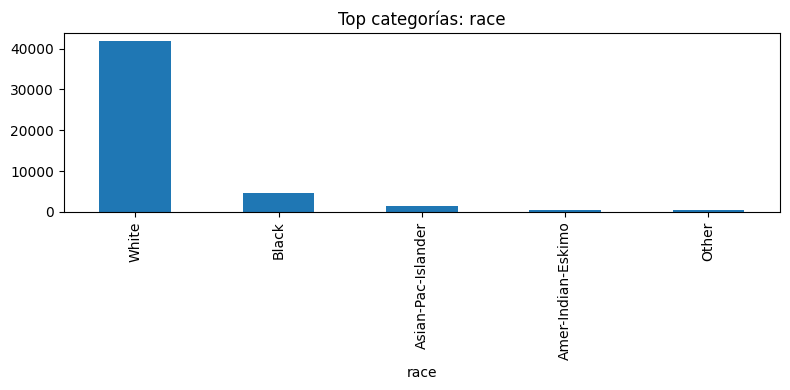


Categorías en sex (top 20):


,freq
sex,
Male,32650
Female,16192


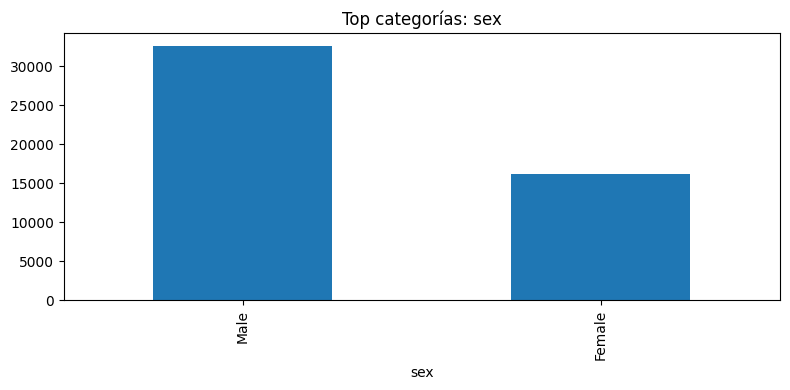


Categorías en native-country (top 20):


,freq
native-country,
United-States,43832
Mexico,951
?,583
Philippines,295
<NA>,274
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155


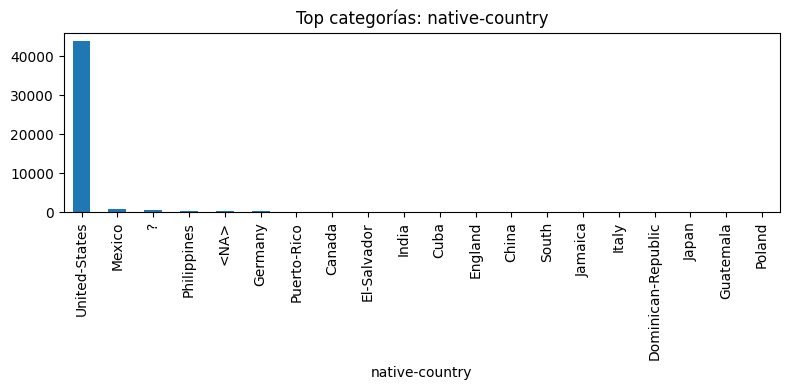


Categorías en income (top 20):


,freq
income,
<=50K,37155
>50K,11687


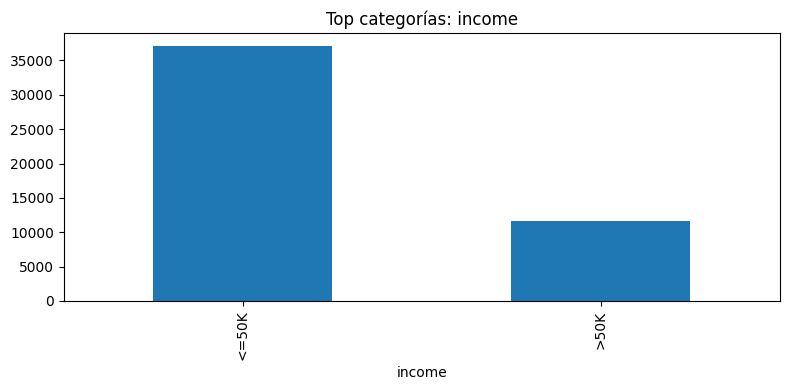

In [43]:

# =======================
# 3) DISTRIBUCIONES
# =======================
df = X.copy()
df['income'] = y['income'].replace({'<=50K.': '<=50K', '>50K.': '>50K'})
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

# numéricas
for c in num_cols:
    s = df[c].dropna()
    if s.empty: 
        continue
    plt.figure()
    s.hist(bins=30)
    plt.title(f"Histograma: {c}")
    plt.xlabel(c); plt.ylabel("Frecuencia")
    plt.tight_layout(); plt.show()
    # métricas extra
    print(f"[{c}] n={s.size} | mean={s.mean():.3f} | std={s.std():.3f} | min={s.min():.3f} | q1={s.quantile(.25):.3f} | median={s.median():.3f} | q3={s.quantile(.75):.3f} | max={s.max():.3f}")

# categóricas
for c in cat_cols:
    vc = df[c].astype("string").value_counts(dropna=False)
    print(f"\nCategorías en {c} (top 20):")
    display(vc.head(20).to_frame("freq"))
    plt.figure(figsize=(8,4))
    vc.head(20).plot(kind="bar")
    plt.title(f"Top categorías: {c}")
    plt.tight_layout(); plt.show()


Estos analisis se hacen con el objetivo de entender la distribucion de cada variable. Se puede usar posiblemente para la imputacion de registros nulos si es el caso. tambien podemos descartar variables en los cuales su concentracion de poblacion solo sea en una categoria ya que no aportan un nivel deterministico eje: native_country


Matriz de correlación (numéricas):


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519
education-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000


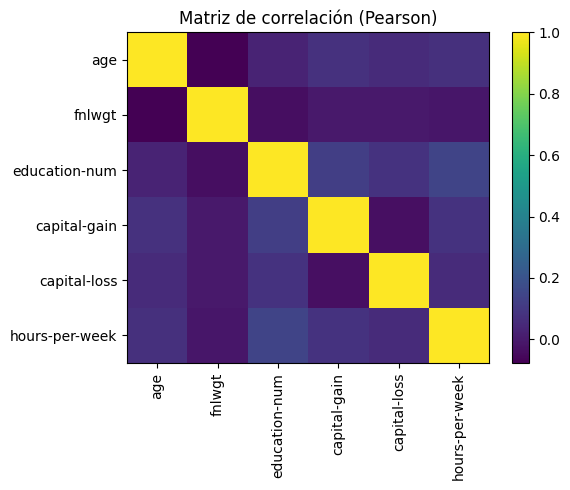

In [39]:

# =======================
# 4) CORRELACIONES
# =======================
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    print("\nMatriz de correlación (numéricas):")
    display(corr)
    plt.figure(figsize=(6,5))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title("Matriz de correlación (Pearson)")
    plt.tight_layout(); plt.show()

Segun el analisis de correlaccion se evidencia que no hay variables que se superpongan en su nivel deterministico

In [40]:

# =======================
# 5) OUTLIERS (IQR)
# =======================
def iqr_outliers(s: pd.Series):
    s = s.dropna()
    if s.empty: return 0, np.nan, np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return int(((s<lo) | (s>hi)).sum()), lo, hi

out_counts = {}
for c in num_cols:
    cnt, lo, hi = iqr_outliers(df[c])
    out_counts[c] = cnt
out_ser = pd.Series(out_counts, name="outliers_IQR").sort_values(ascending=False)
print("\nOutliers por columna numérica (IQR):")
display(out_ser.to_frame())



Outliers por columna numérica (IQR):


,outliers_IQR
hours-per-week,13496
capital-gain,4035
capital-loss,2282
education-num,1794
fnlwgt,1453
age,216


Este analisis intercuantil nos permite ver cuantos valores estan por fuera del rango intercuartilico por cada feature. estos datos hacen parte de la distribucion de los datos por lo tanto los dejaremos y no se van a eliminar

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Se procede a hacer un analisis bi-variado para ver el nivel deterministico de cada feature vs la variable objetivo


=== sex vs income (Categórica) ===


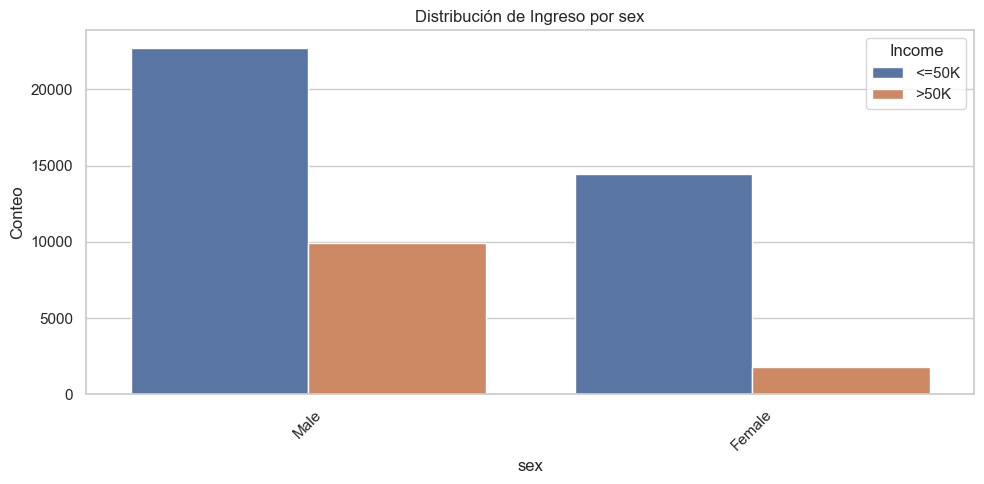

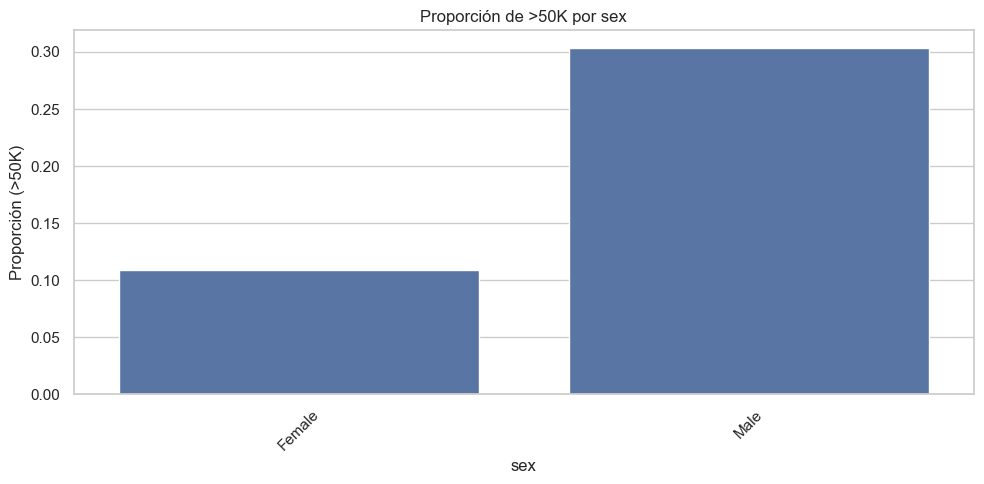

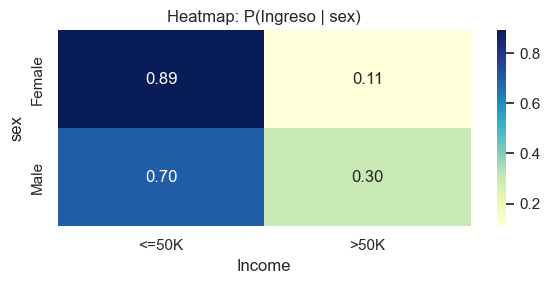

Chi2 = 2248.85 | dof = 1 | p-valor = 0.000000
➡ Existe relación estadísticamente significativa entre 'sex' e 'income'

=== race vs income (Categórica) ===


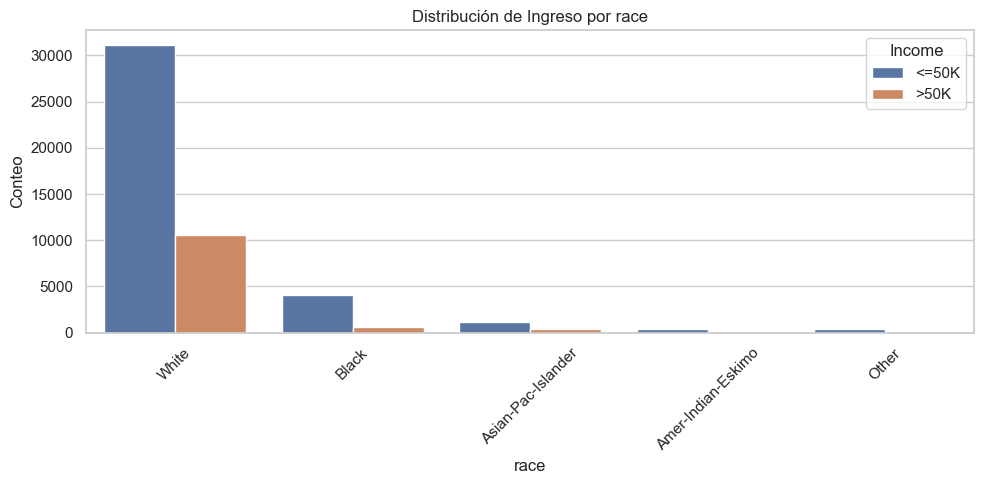

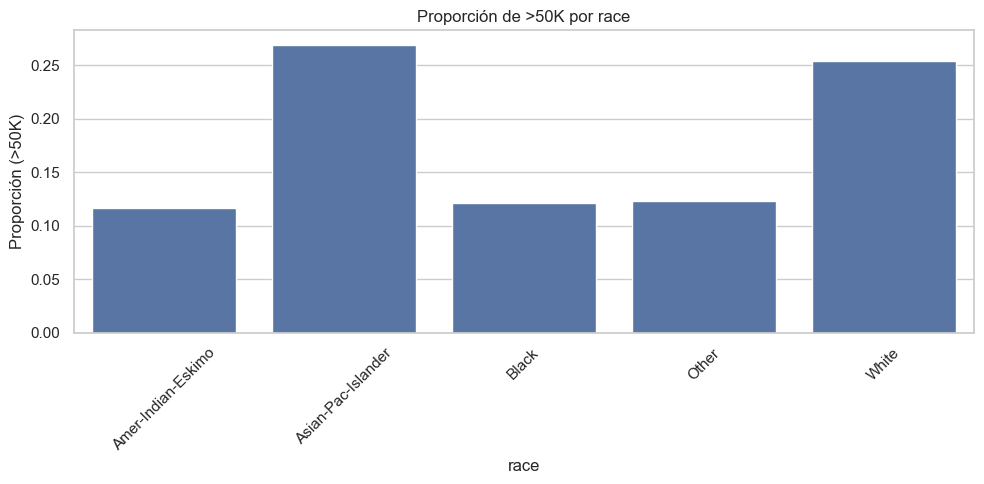

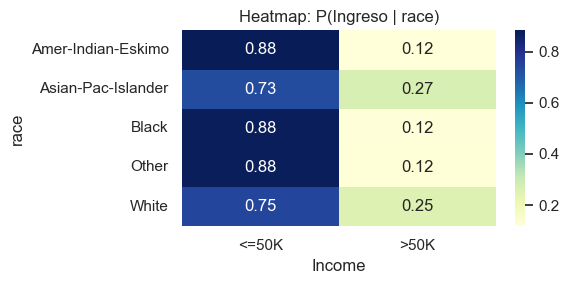

Chi2 = 487.03 | dof = 4 | p-valor = 0.000000
➡ Existe relación estadísticamente significativa entre 'race' e 'income'

=== relationship vs income (Categórica) ===


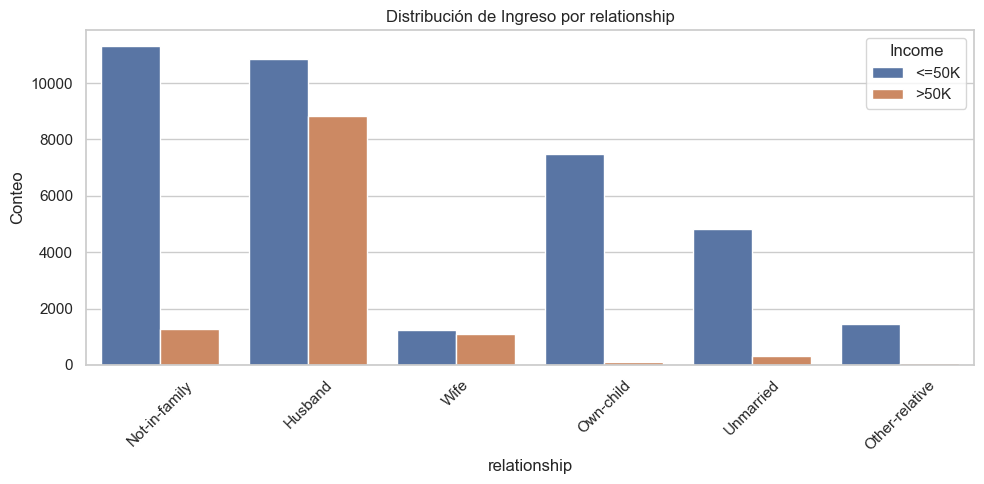

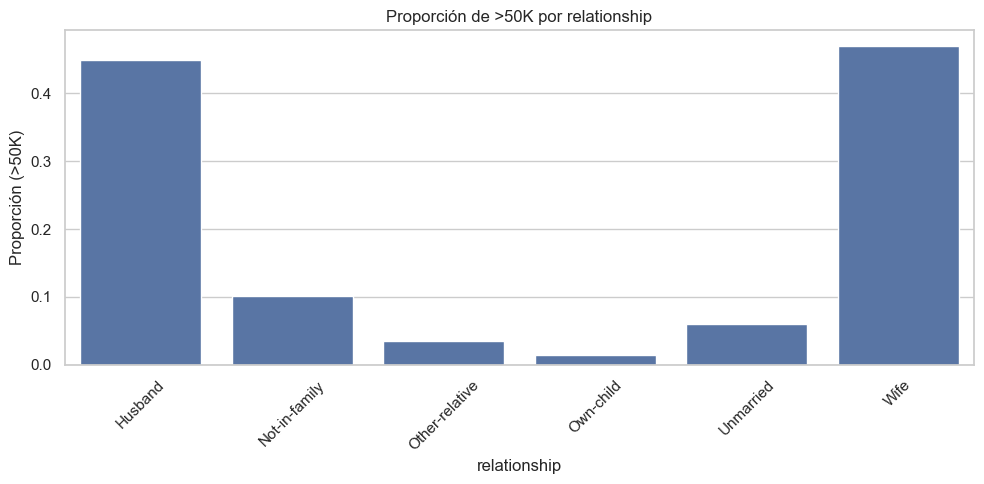

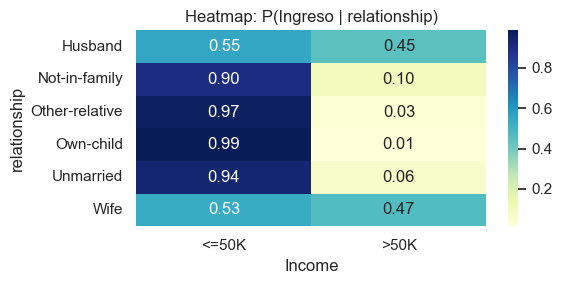

Chi2 = 10088.72 | dof = 5 | p-valor = 0.000000
➡ Existe relación estadísticamente significativa entre 'relationship' e 'income'

=== occupation vs income (Categórica) ===


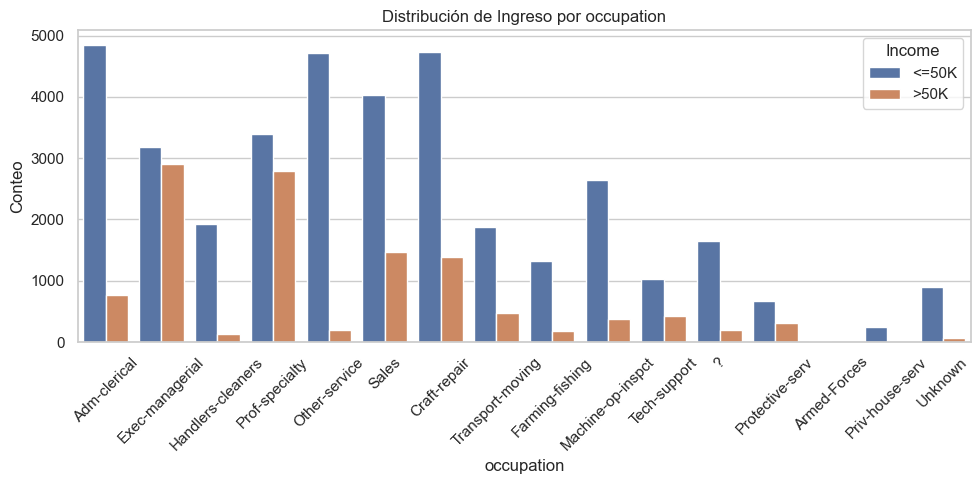

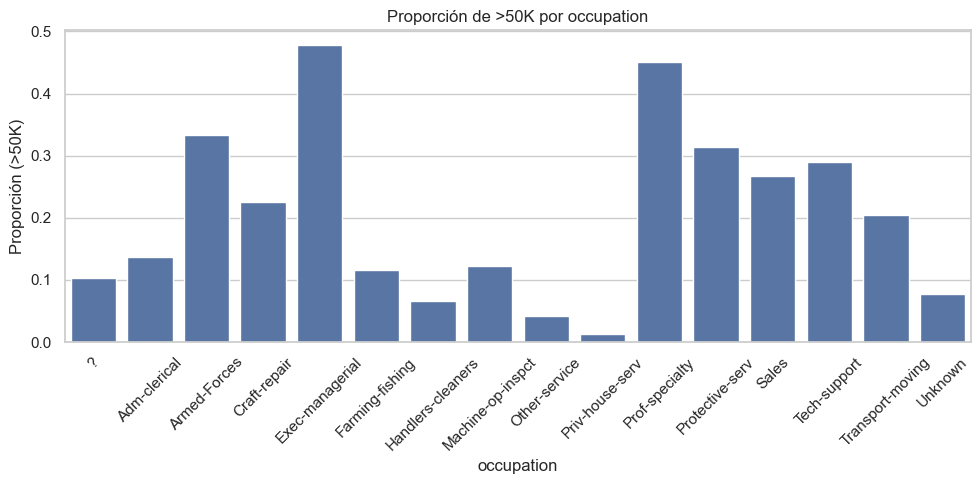

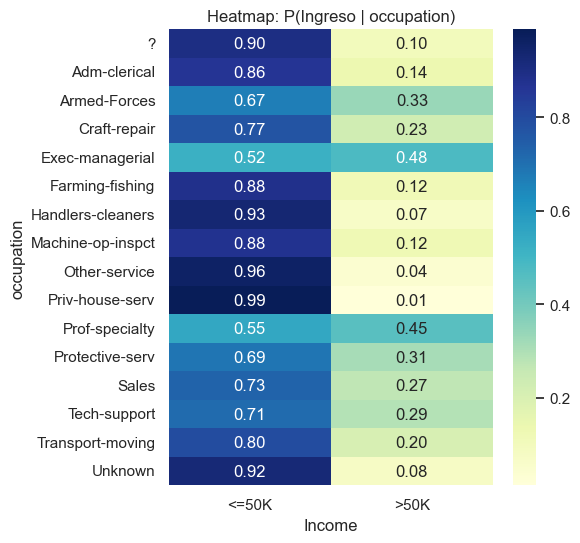

Chi2 = 5985.71 | dof = 15 | p-valor = 0.000000
➡ Existe relación estadísticamente significativa entre 'occupation' e 'income'

=== education vs income (Categórica) ===


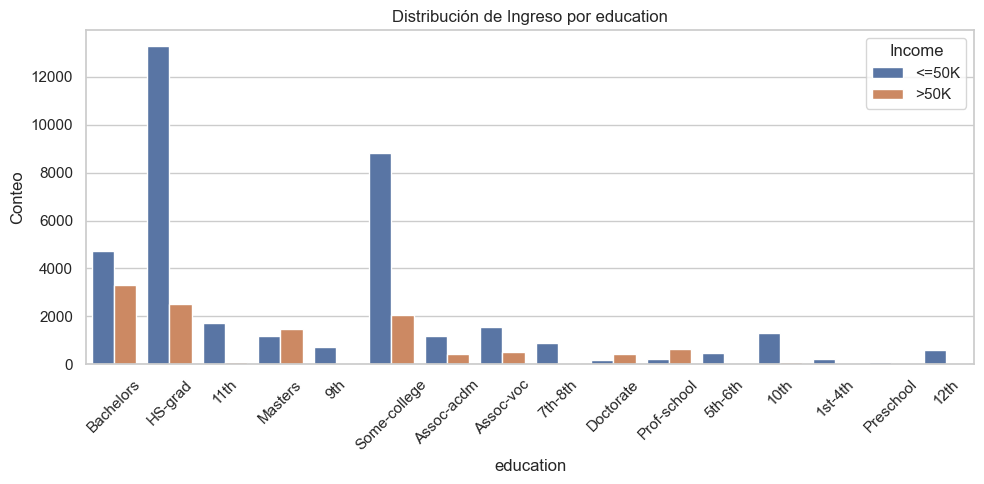

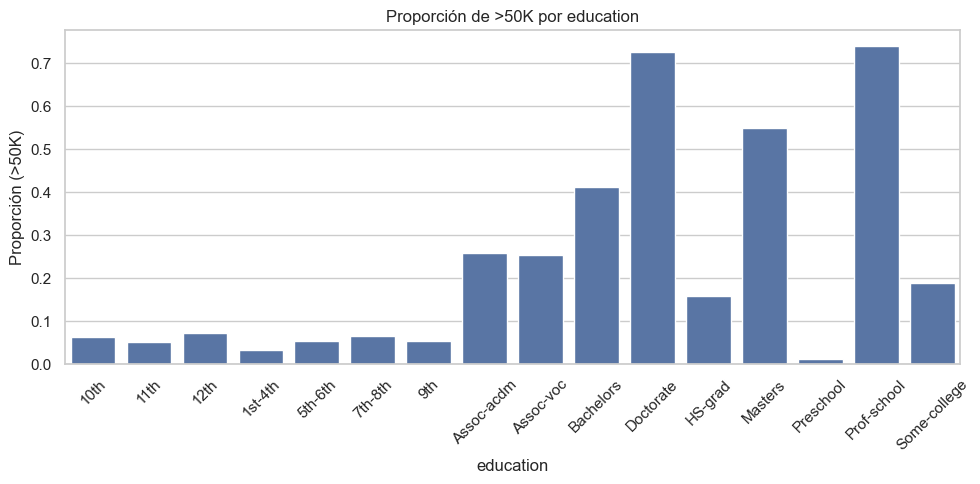

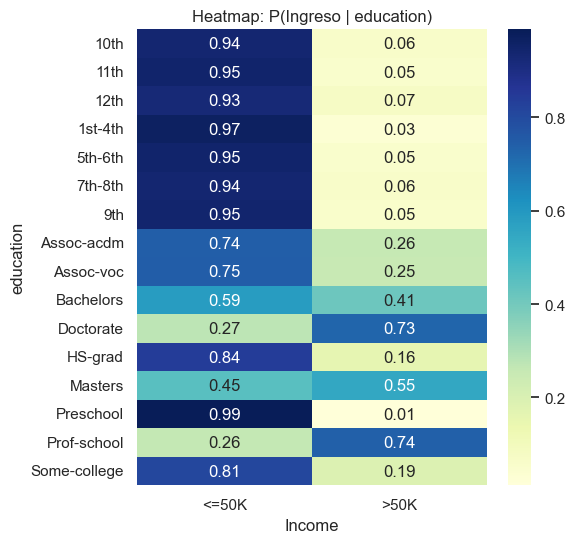

Chi2 = 6537.97 | dof = 15 | p-valor = 0.000000
➡ Existe relación estadísticamente significativa entre 'education' e 'income'

=== marital-status vs income (Categórica) ===


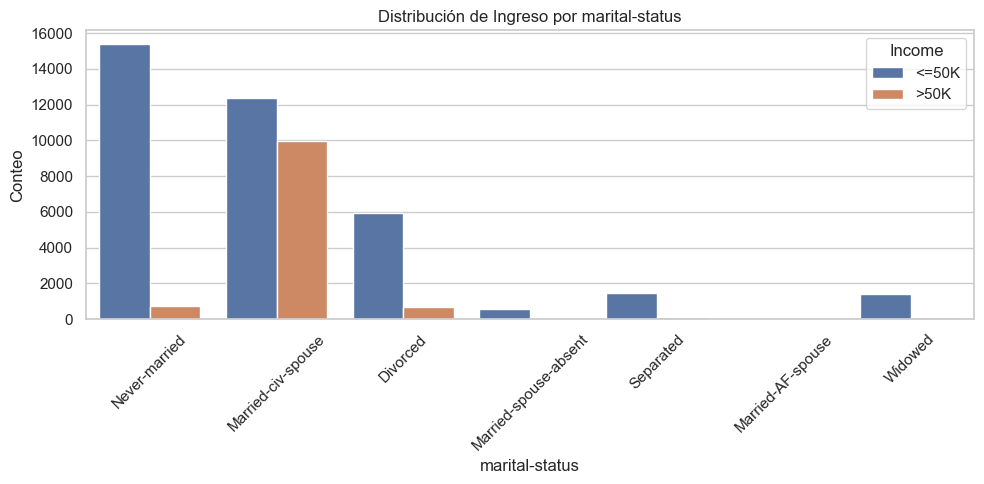

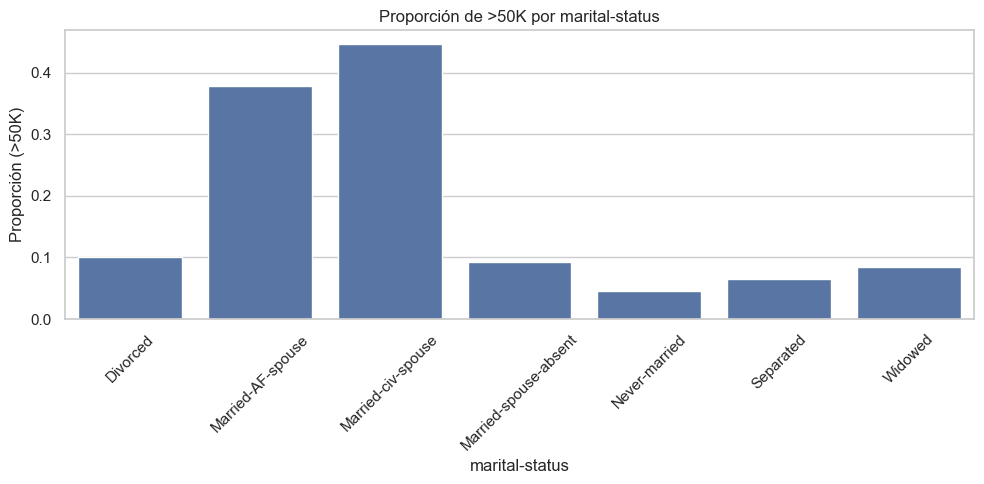

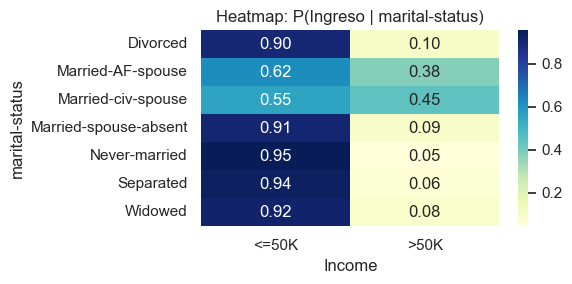

Chi2 = 9816.02 | dof = 6 | p-valor = 0.000000
➡ Existe relación estadísticamente significativa entre 'marital-status' e 'income'

=== age vs income (Numérica) ===


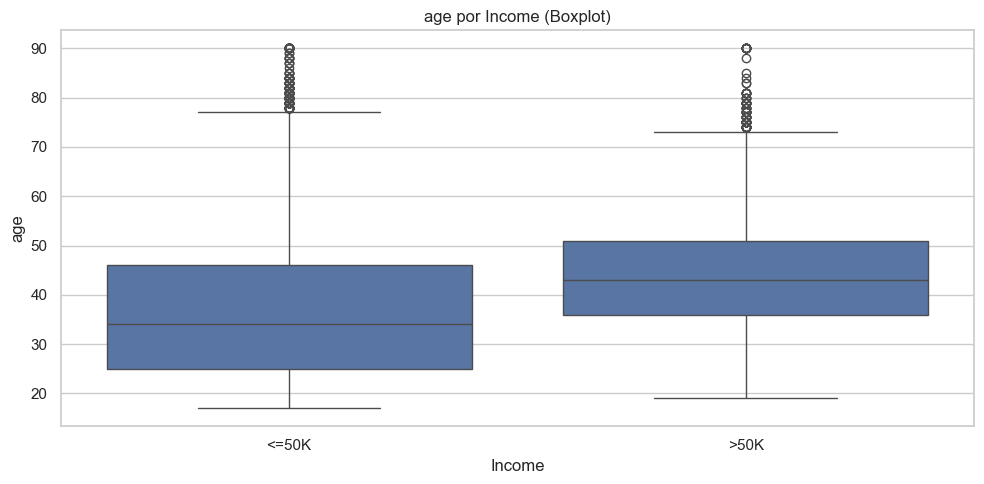

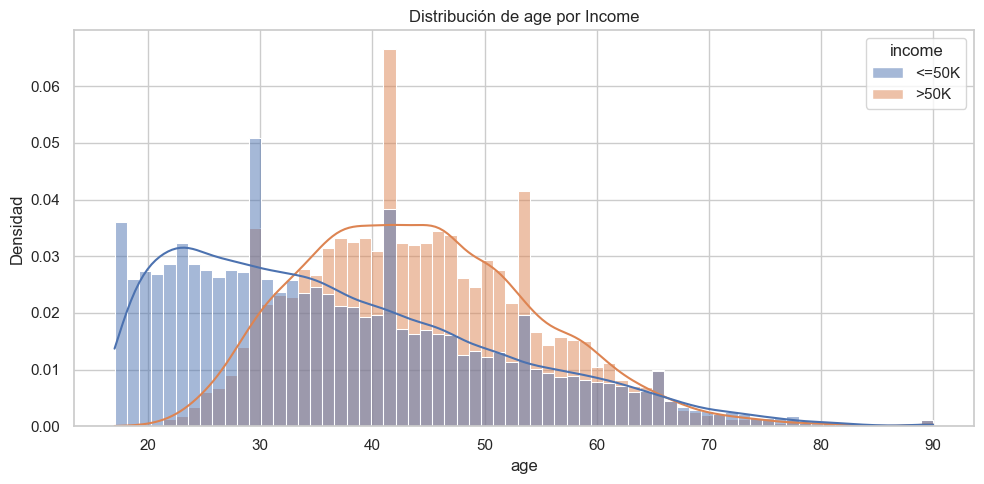

C:\Users\juan-\AppData\Local\Temp\ipykernel_6340\20598844.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop_bin = (dfx.groupby('_bin')['income']


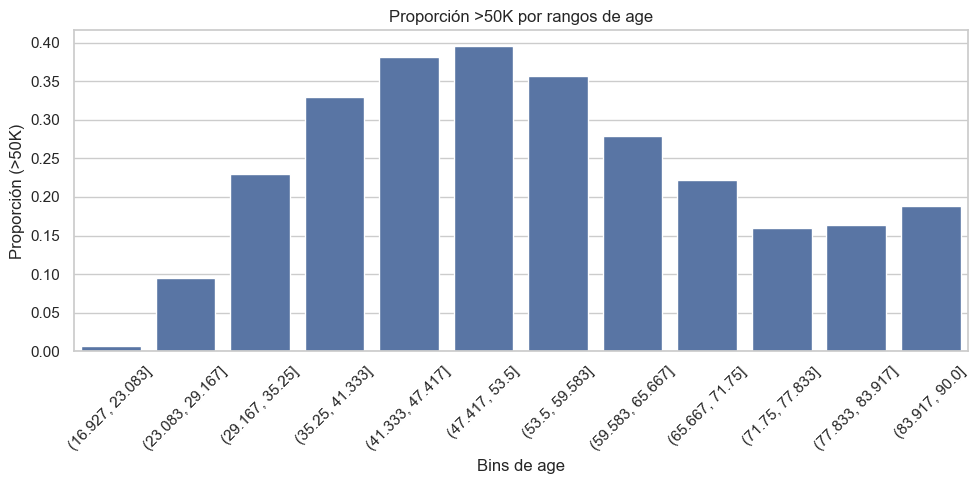

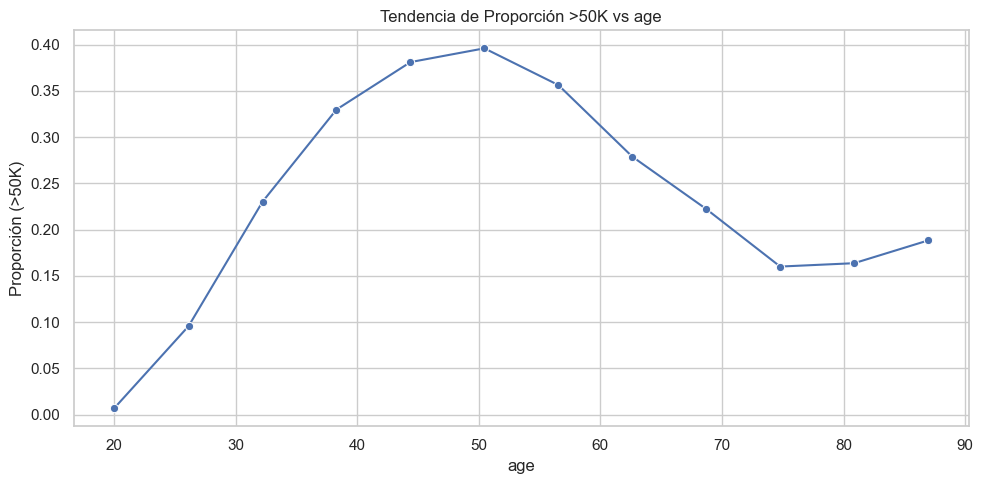

In [56]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


# Variables a analizar
categorical_vars = ['sex', 'race', 'relationship', 'occupation', 'education', 'marital-status']
numeric_vars = ['age']

# Funciones de graficación

def plot_categorical_vs_income(df, var):
    print(f"\n=== {var} vs income (Categórica) ===")
    dfx = df[[var, 'income']].copy()
    dfx[var] = dfx[var].fillna('Unknown')

    # 1) Countplot
    plt.figure()
    sns.countplot(data=dfx, x=var, hue='income')
    plt.title(f'Distribución de Ingreso por {var}')
    plt.xlabel(var)
    plt.ylabel('Conteo')
    plt.xticks(rotation=45)
    plt.legend(title='Income')
    plt.tight_layout()
    plt.show()

    # 2) Proporción de >50K por categoría
    prop = (dfx.groupby(var)['income']
              .value_counts(normalize=True)
              .rename('proportion')
              .reset_index())
    plt.figure()
    sns.barplot(data=prop[prop['income']=='>50K'], x=var, y='proportion')
    plt.title(f'Proporción de >50K por {var}')
    plt.xlabel(var)
    plt.ylabel('Proporción (>50K)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3) Heatmap de contingencia normalizada por fila
    crosstab = pd.crosstab(dfx[var], dfx['income'], normalize='index')
    plt.figure(figsize=(6, max(3, 0.35*len(crosstab))))
    sns.heatmap(crosstab, annot=True, cmap='YlGnBu', fmt=".2f")
    plt.title(f'Heatmap: P(Ingreso | {var})')
    plt.xlabel('Income')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

    # 4) Test Chi-cuadrado de independencia
    tabla = pd.crosstab(dfx[var], dfx['income'])
    chi2, p, dof, expected = chi2_contingency(tabla)
    print(f"Chi2 = {chi2:.2f} | dof = {dof} | p-valor = {p:.6f}")
    if p < 0.05:
        print(f"➡ Existe relación estadísticamente significativa entre '{var}' e 'income'")
    else:
        print(f"❌ No hay evidencia estadística de relación entre '{var}' e 'income'")

def plot_numeric_vs_income(df, var, bins=10):
    print(f"\n=== {var} vs income (Numérica) ===")
    dfx = df[[var, 'income']].dropna().copy()

    # 1) Boxplot por income
    plt.figure()
    sns.boxplot(data=dfx, x='income', y=var)
    plt.title(f'{var} por Income (Boxplot)')
    plt.xlabel('Income')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.histplot(data=dfx, x=var, hue='income', kde=True, stat='density', common_norm=False)
    plt.title(f'Distribución de {var} por Income')
    plt.xlabel(var)
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

    dfx['_bin'] = pd.cut(dfx[var], bins=bins, duplicates='drop')
    prop_bin = (dfx.groupby('_bin')['income']
                  .apply(lambda s: (s=='>50K').mean())
                  .reset_index(name='prop_gt_50k'))
    prop_bin['bin_center'] = prop_bin['_bin'].apply(lambda b: (b.left + b.right)/2)

    plt.figure()
    sns.barplot(data=prop_bin, x='_bin', y='prop_gt_50k')
    plt.title(f'Proporción >50K por rangos de {var}')
    plt.xlabel(f'Bins de {var}')
    plt.ylabel('Proporción (>50K)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.lineplot(data=prop_bin, x='bin_center', y='prop_gt_50k', marker='o')
    plt.title(f'Tendencia de Proporción >50K vs {var}')
    plt.xlabel(var)
    plt.ylabel('Proporción (>50K)')
    plt.tight_layout()
    plt.show()

for var in categorical_vars:
    plot_categorical_vs_income(df, var)
for var in numeric_vars:
    plot_numeric_vs_income(df, var, bins=12) 

In [57]:
vars_to_check = ['marital-status', 'sex', 'race', 'relationship', 'occupation', 'education', 'age']

# Si quieres forzar qué es numérico vs categórico, define estas listas. Si no, el código infiere por dtype.
categorical_vars = ['marital-status', 'sex', 'race', 'relationship', 'occupation', 'education']
numeric_vars = ['age']

# ---- Helper: Cramér's V con corrección de sesgo (Bergsma 2013) ----
def cramers_v_corrected(conf_matrix: pd.DataFrame) -> float:
    chi2, _, _, _ = chi2_contingency(conf_matrix)
    n = conf_matrix.values.sum()
    phi2 = chi2 / n
    r, k = conf_matrix.shape
    phi2_corr = max(0, phi2 - (k-1)*(r-1)/(n-1))
    r_corr = r - (r-1)**2/(n-1)
    k_corr = k - (k-1)**2/(n-1)
    denom = min((k_corr-1), (r_corr-1))
    return np.sqrt(phi2_corr / denom) if denom > 0 else np.nan

# ---- Helper: binning seguro para numéricas ----
def safe_bin(s: pd.Series, q=10):
    s = s.dropna()
    try:
        return pd.qcut(s, q=q, duplicates='drop')
    except Exception:
        # Si qcut falla (muchos duplicados), intenta bins de igual ancho
        return pd.cut(s, bins=min(q, max(2, s.nunique())), duplicates='drop')

# ---- Loop de análisis Chi-cuadrado para todas las variables ----
results = []
for var in vars_to_check:
    dfx = df[[var, 'income']].copy()

    # Preparar variable (categorizar si es numérica)
    if (var in numeric_vars) or (dfx[var].dtype.kind in 'ifc'):
        # Binning para poder usar chi-cuadrado
        binned = safe_bin(dfx[var])
        dfx[var] = binned
        var_label = f"{var} (binned)"
    else:
        dfx[var] = dfx[var].astype('object').fillna('Unknown')
        var_label = var

    # Quitar filas con NA en var o income
    dfx = dfx.dropna(subset=[var, 'income'])

    # Tabla de contingencia
    tabla = pd.crosstab(dfx[var], dfx['income'])

    # Hay que tener al menos 2 columnas/filas con conteos > 0
    if (tabla.shape[0] < 2) or (tabla.shape[1] < 2):
        print(f"⚠ {var_label}: no es posible calcular chi-cuadrado (tabla insuficiente).")
        results.append({'variable': var_label, 'chi2': np.nan, 'p_value': np.nan, 'dof': np.nan, 'cramers_v': np.nan})
        continue

    # Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(tabla)

    # Cramér's V
    cv = cramers_v_corrected(tabla)

    # Output por variable
    print(f"\n=== {var_label} vs income ===")
    print(f"Chi2 = {chi2:.2f} | dof = {dof} | p-valor = {p:.6f} | Cramér's V = {cv:.3f}")
    if p < 0.05:
        print(f"➡ Existe relación estadísticamente significativa entre '{var_label}' e 'income'")
    else:
        print(f"❌ No hay evidencia estadística de relación entre '{var_label}' e 'income'")

    results.append({'variable': var_label, 'chi2': chi2, 'p_value': p, 'dof': dof, 'cramers_v': cv})

# ---- Resumen ordenado por significancia ----
summary = pd.DataFrame(results).sort_values(['p_value', 'cramers_v'], ascending=[True, False])
print("\n\nResumen (ordenado por p-valor ascendente):")
display(summary)


=== marital-status vs income ===
Chi2 = 9816.02 | dof = 6 | p-valor = 0.000000 | Cramér's V = 0.448
➡ Existe relación estadísticamente significativa entre 'marital-status' e 'income'

=== sex vs income ===
Chi2 = 2248.85 | dof = 1 | p-valor = 0.000000 | Cramér's V = 0.215
➡ Existe relación estadísticamente significativa entre 'sex' e 'income'

=== race vs income ===
Chi2 = 487.03 | dof = 4 | p-valor = 0.000000 | Cramér's V = 0.099
➡ Existe relación estadísticamente significativa entre 'race' e 'income'

=== relationship vs income ===
Chi2 = 10088.72 | dof = 5 | p-valor = 0.000000 | Cramér's V = 0.454
➡ Existe relación estadísticamente significativa entre 'relationship' e 'income'

=== occupation vs income ===
Chi2 = 5985.71 | dof = 15 | p-valor = 0.000000 | Cramér's V = 0.350
➡ Existe relación estadísticamente significativa entre 'occupation' e 'income'

=== education vs income ===
Chi2 = 6537.97 | dof = 15 | p-valor = 0.000000 | Cramér's V = 0.365
➡ Existe relación estadísticamente s

,variable,chi2,p_value,dof,cramers_v
3,relationship,10088.722490,0.000000e+00,5,0.454379
0,marital-status,9816.015037,0.000000e+00,6,0.448170
5,education,6537.972961,0.000000e+00,15,0.365452
4,occupation,5985.707962,0.000000e+00,15,0.349640
6,age (binned),4964.359839,0.000000e+00,9,0.318526
1,sex,2248.847679,0.000000e+00,1,0.214532
2,race,487.026287,4.284378e-104,4,0.099447


Conclusiones:
    - Hay features en las que se observa un nivel deterministico alto frente a la variable objetivo.
    - Hay features donde su poblacion se centra en una sola categoria, por lo tanto estas variables pueden ser descartadas por el modelo.
    - En los analisis hay variables que, aunque su nivel deterministico vs la variable respuesta es alto, estas pueden generar riesgos discriminativos y eticos, como el caso de la raza o el sexo, por lo tanto no se usaran.
    - Las variables no presentan correlacion entre ellas.
  